# 05.04 — Model Evaluation and Calibration

## Purpose

Load the selected baseline and evaluate train, validation, and untouched test data
separately. Measure discrimination, probability quality, calibration, and gain-based
feature importance.

## Setup

In [4]:
from pathlib import Path
import json
import platform

import numpy as np
import pandas as pd
import pyarrow.parquet as pq

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CURRENT_PATH = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (CURRENT_PATH, *CURRENT_PATH.parents)
     if (path / "README.md").is_file() and (path / ".git").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the movie_rating_predictor repository root")

FEATURE_PATH = PROJECT_ROOT / "data" / "features" / "rating_features_v1.parquet"
FEATURE_METADATA_PATH = PROJECT_ROOT / "data" / "features" / "rating_features_v1.metadata.json"
RATINGS_PATH = PROJECT_ROOT / "data" / "processed" / "ratings.parquet"
MODELS_DIR = PROJECT_ROOT / "models" / "history" / "phase5"

FEATURE_COLUMNS = [
    "global_rating_count",
    "global_mean_rating",
    "user_rating_count",
    "user_mean_rating",
    "user_rating_std_pop",
    "user_seconds_since_last_rating",
    "movie_rating_count",
    "movie_mean_rating",
    "movie_rating_std_pop",
    "movie_rating_count_30d",
    "user_target_genre_rating_count",
    "user_target_genre_mean_rating",
    "user_target_genre_mean_delta",
    "movie_genre_count",
    "movie_release_year",
    "movie_release_year_missing",
    "movie_age_years",
]

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Random seed:", RANDOM_SEED)
print("Feature count:", len(FEATURE_COLUMNS))
print("Features:", FEATURE_COLUMNS)


TRAIN_END = pd.Timestamp("2012-01-01")
VALIDATION_END = pd.Timestamp("2014-01-01")

SPLIT_DEFINITIONS = {
    "train": {"start": None, "end": TRAIN_END},
    "validation": {"start": TRAIN_END, "end": VALIDATION_END},
    "test": {"start": VALIDATION_END, "end": None},
}

def split_mask(timestamp: pd.Series, split_name: str) -> np.ndarray:
    bounds = SPLIT_DEFINITIONS[split_name]
    mask = np.ones(len(timestamp), dtype=bool)
    if bounds["start"] is not None:
        mask &= timestamp.to_numpy() >= bounds["start"].to_datetime64()
    if bounds["end"] is not None:
        mask &= timestamp.to_numpy() < bounds["end"].to_datetime64()
    return mask

Python: 3.14.6
pandas: 3.0.5
NumPy: 2.5.3
Random seed: 42
Feature count: 17
Features: ['global_rating_count', 'global_mean_rating', 'user_rating_count', 'user_mean_rating', 'user_rating_std_pop', 'user_seconds_since_last_rating', 'movie_rating_count', 'movie_mean_rating', 'movie_rating_std_pop', 'movie_rating_count_30d', 'user_target_genre_rating_count', 'user_target_genre_mean_rating', 'user_target_genre_mean_delta', 'movie_genre_count', 'movie_release_year', 'movie_release_year_missing', 'movie_age_years']


In [5]:
import gc
import matplotlib.pyplot as plt
import sklearn
import xgboost as xgb
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_curve
from xgboost import XGBClassifier

print("scikit-learn:", sklearn.__version__)
print("XGBoost:", xgb.__version__)
rating_values = pd.read_parquet(RATINGS_PATH, columns=["rating"])["rating"].to_numpy(dtype=np.float32, copy=False)

def load_split(split_name: str, extra_columns=()):
    """Load one half-open temporal partition and attach labels by event identity."""
    bounds = SPLIT_DEFINITIONS[split_name]
    filters = []
    if bounds["start"] is not None:
        filters.append(("timestamp", ">=", bounds["start"]))
    if bounds["end"] is not None:
        filters.append(("timestamp", "<", bounds["end"]))

    columns = list(dict.fromkeys(["ratingEventId", "timestamp", *FEATURE_COLUMNS, *extra_columns]))
    frame = pd.read_parquet(FEATURE_PATH, columns=columns, filters=filters or None)
    if bounds["start"] is not None:
        frame = frame.loc[frame["timestamp"] >= bounds["start"]]
    if bounds["end"] is not None:
        frame = frame.loc[frame["timestamp"] < bounds["end"]]

    event_ids = frame["ratingEventId"].to_numpy(dtype=np.uint64, copy=False)
    if event_ids.min() < 1 or event_ids.max() > len(rating_values):
        raise AssertionError("ratingEventId is outside the canonical ratings row range")
    y = (rating_values[event_ids - 1] >= 4.0).astype(np.int8)
    return frame.reset_index(drop=True), y

def as_float32_matrix(frame: pd.DataFrame) -> np.ndarray:
    """Create the single compact dense matrix handed to XGBoost."""
    return frame.loc[:, FEATURE_COLUMNS].to_numpy(dtype=np.float32, copy=True)


from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
)

def binary_metrics(y_true, probability):
    return {
        "Rows": len(y_true),
        "Prevalence": float(np.mean(y_true)),
        "ROC-AUC": roc_auc_score(y_true, probability),
        "PR-AUC": average_precision_score(y_true, probability),
        "Log Loss": log_loss(y_true, probability, labels=[0, 1]),
        "Brier": brier_score_loss(y_true, probability),
    }

scikit-learn: 1.9.1
XGBoost: 3.4.1


## Load the persisted baseline

In [6]:
model_path = MODELS_DIR / "xgboost_baseline_v1.json"
run_metadata = json.loads((MODELS_DIR / "xgboost_baseline_v1.metadata.json").read_text())
assert run_metadata["feature_columns"] == FEATURE_COLUMNS
model = XGBClassifier()
model.load_model(model_path)
print("Best iteration:", model.best_iteration)
print("Saved parameters:", run_metadata["model_params"])

Best iteration: 597
Saved parameters: {'objective': 'binary:logistic', 'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.9, 'min_child_weight': 20, 'reg_alpha': 0.1, 'reg_lambda': 2.0, 'max_bin': 128, 'tree_method': 'hist', 'eval_metric': ['logloss', 'auc', 'aucpr'], 'early_stopping_rounds': 30, 'random_state': 42, 'n_jobs': 8}


## Metrics by split

Each partition is loaded, scored, and released in turn to cap memory. Full data are
used for metrics; deterministic subsamples are retained only for display curves.

In [7]:
rng = np.random.default_rng(RANDOM_SEED)
MAX_CURVE_ROWS = 2_000_000
metrics_by_split = {}
curve_data = {}

for split_name in ("train", "validation", "test"):
    frame, y_split = load_split(split_name)
    X_split = as_float32_matrix(frame)
    probability = model.predict_proba(X_split)[:, 1]
    metrics_by_split[split_name] = binary_metrics(y_split, probability)

    if len(y_split) > MAX_CURVE_ROWS:
        selected = np.sort(rng.choice(len(y_split), MAX_CURVE_ROWS, replace=False))
    else:
        selected = np.arange(len(y_split))
    curve_data[split_name] = (y_split[selected], probability[selected])

    if split_name == "test":
        test_y = y_split.copy()
        test_probability = probability.copy()
    del frame, X_split, y_split, probability
    gc.collect()

metric_table = pd.DataFrame(metrics_by_split).T
metric_table.index.name = "Split"
display(metric_table[["Rows", "Prevalence", "ROC-AUC", "PR-AUC", "Log Loss", "Brier"]])

,Rows,Prevalence,ROC-AUC,PR-AUC,Log Loss,Brier
Split,,,,,,
train,17822773.0,0.498194,0.798314,0.783246,0.541610,0.182881
validation,1330716.0,0.519539,0.797312,0.797281,0.542776,0.183097
test,846774.0,0.501728,0.795275,0.779945,0.548997,0.185277


## ROC and precision-recall curves

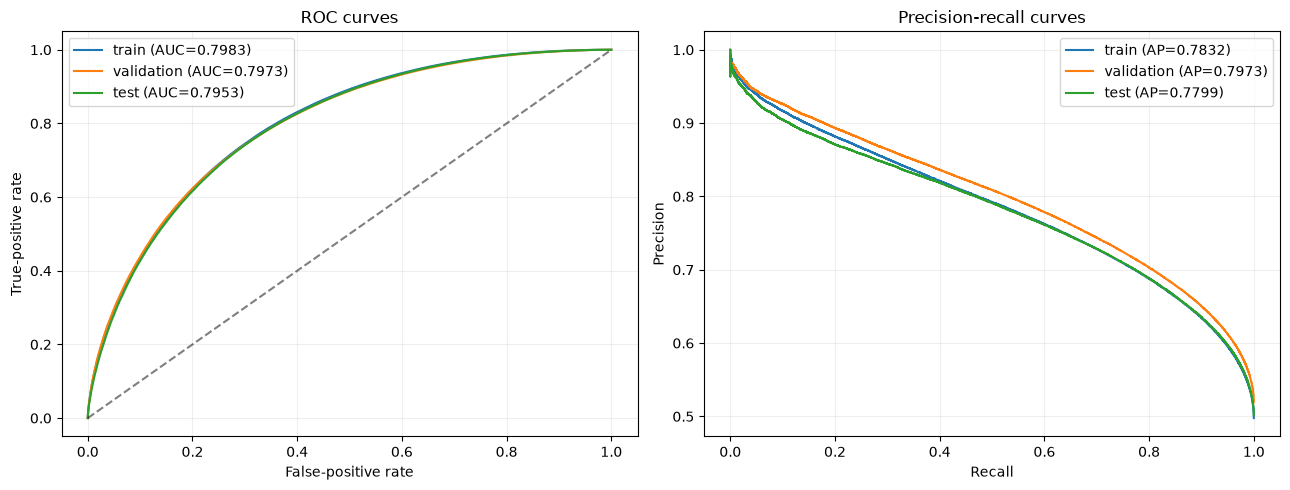

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for split_name, (y_curve, p_curve) in curve_data.items():
    fpr, tpr, _ = roc_curve(y_curve, p_curve)
    precision, recall, _ = precision_recall_curve(y_curve, p_curve)
    axes[0].plot(fpr, tpr, label=f'{split_name} (AUC={metrics_by_split[split_name]["ROC-AUC"]:.4f})')
    axes[1].plot(recall, precision, label=f'{split_name} (AP={metrics_by_split[split_name]["PR-AUC"]:.4f})')
axes[0].plot([0, 1], [0, 1], "k--", alpha=.5)
axes[0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curves")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curves")
for ax in axes:
    ax.legend()
    ax.grid(alpha=.2)
plt.tight_layout()
plt.show()

## Score distributions

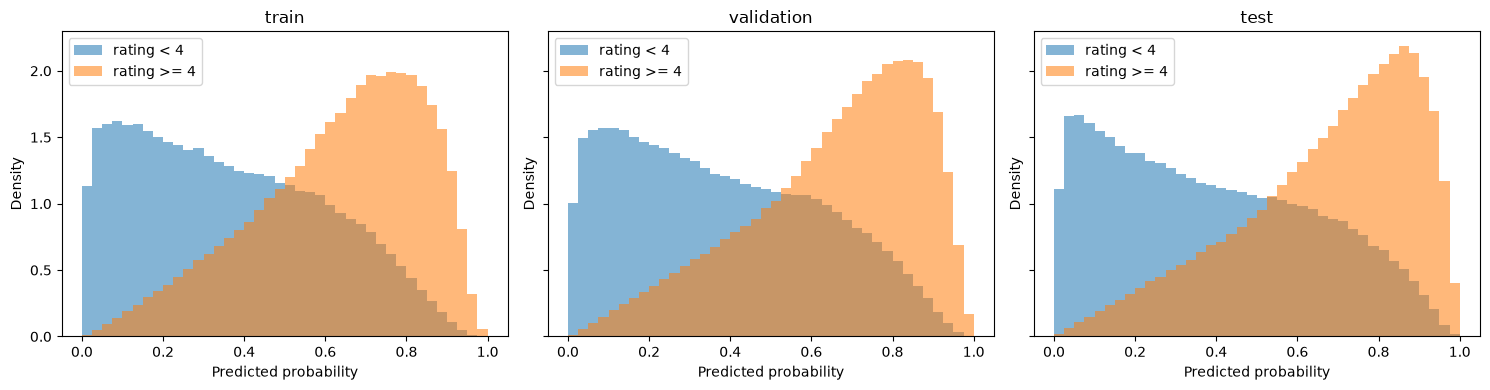

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)
bins = np.linspace(0, 1, 41)
for ax, (split_name, (y_curve, p_curve)) in zip(axes, curve_data.items()):
    ax.hist(p_curve[y_curve == 0], bins=bins, density=True, alpha=.55, label="rating < 4")
    ax.hist(p_curve[y_curve == 1], bins=bins, density=True, alpha=.55, label="rating >= 4")
    ax.set(title=split_name, xlabel="Predicted probability", ylabel="Density")
    ax.legend()
plt.tight_layout()
plt.show()

## Test calibration

The reliability curve and equal-width probability-bin table measure calibration before
any recalibration experiment. Sparse empty bins are omitted.

,rows,average_prediction,observed_prevalence
probability_bin,,,
"(-0.001, 0.1]",67319,0.054283,0.052511
"(0.1, 0.2]",72804,0.149741,0.149429
"(0.2, 0.3]",74049,0.250195,0.248484
"(0.3, 0.4]",75477,0.350496,0.342290
"(0.4, 0.5]",80034,0.450690,0.424020
"(0.5, 0.6]",89966,0.551266,0.518229
"(0.6, 0.7]",101021,0.650760,0.610418
"(0.7, 0.8]",111120,0.750426,0.704086
"(0.8, 0.9]",112926,0.849436,0.799887


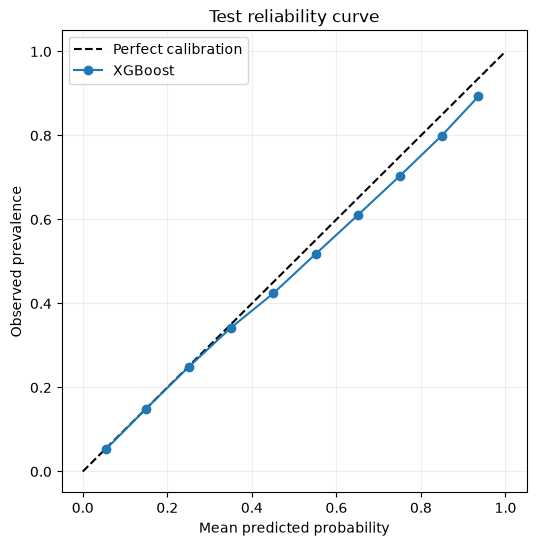

Test Brier score: 0.18527650833129883


In [10]:
fraction_positive, mean_predicted = calibration_curve(test_y, test_probability, n_bins=10, strategy="uniform")

calibration_frame = pd.DataFrame({"y": test_y, "probability": test_probability})
calibration_frame["probability_bin"] = pd.cut(
    calibration_frame["probability"], bins=np.linspace(0, 1, 11), include_lowest=True
)
calibration_table = calibration_frame.groupby("probability_bin", observed=True).agg(
    rows=("y", "size"),
    average_prediction=("probability", "mean"),
    observed_prevalence=("y", "mean"),
)
display(calibration_table)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.plot(mean_predicted, fraction_positive, marker="o", label="XGBoost")
ax.set(xlabel="Mean predicted probability", ylabel="Observed prevalence", title="Test reliability curve")
ax.grid(alpha=.2)
ax.legend()
plt.show()
print("Test Brier score:", metrics_by_split["test"]["Brier"])

## Gain feature importance

,gain
movie_mean_rating,6463.581543
user_target_genre_mean_rating,5806.793945
user_mean_rating,697.760010
user_rating_std_pop,419.227692
user_rating_count,264.941193
movie_rating_std_pop,264.392303
global_rating_count,228.934753
user_target_genre_rating_count,217.155594
movie_rating_count_30d,212.833710
movie_release_year,185.067230


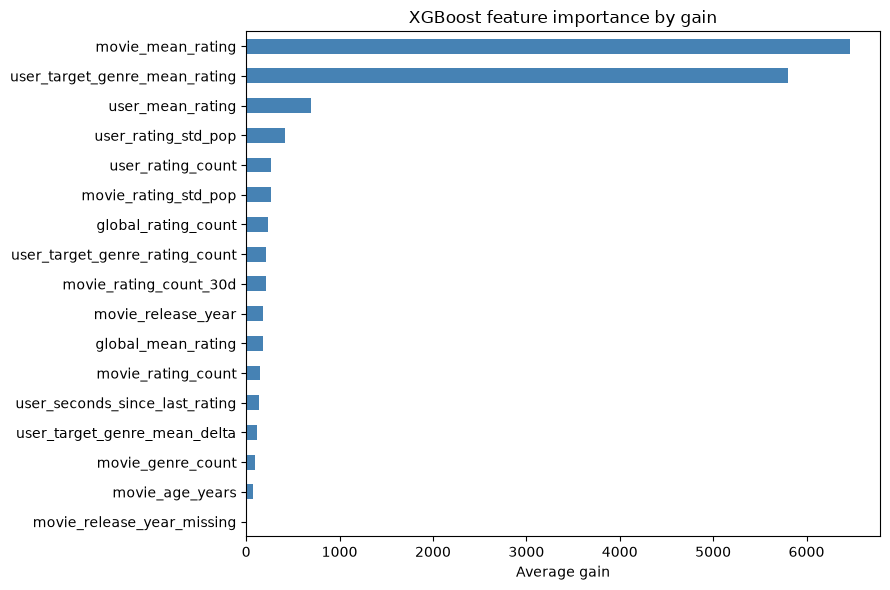

In [11]:
gain = model.get_booster().get_score(importance_type="gain")
importance = pd.Series({name: gain.get(f"f{i}", 0.0) for i, name in enumerate(FEATURE_COLUMNS)}, name="gain")
importance = importance.sort_values(ascending=True)
display(importance.sort_values(ascending=False).to_frame())

ax = importance.plot.barh(figsize=(9, 6), color="steelblue", title="XGBoost feature importance by gain")
ax.set_xlabel("Average gain")
plt.tight_layout()
plt.show()

## Persist evaluation summary

In [12]:
evaluation_path = MODELS_DIR / "xgboost_baseline_v1.evaluation.json"
evaluation_payload = {
    "metrics": metric_table.to_dict(orient="index"),
    "gain_importance": importance.sort_values(ascending=False).to_dict(),
    "calibration_bins": {
        str(index): {key: (int(value) if key == "rows" else float(value)) for key, value in row.items()}
        for index, row in calibration_table.to_dict(orient="index").items()
    },
}
evaluation_path.write_text(json.dumps(evaluation_payload, indent=2) + "\n")
print("Saved:", evaluation_path.relative_to(PROJECT_ROOT))

Saved: models/history/phase5/xgboost_baseline_v1.evaluation.json
